<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/notebooks/19_KMeans_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 테슬라(TSLA) 시장 국면(Regime) 분석: K-Means 군집화

이 분석은 머신러닝의 비지도학습(Unsupervised Learning) 기법을 사용하여 주식 시장의 다양한 상태를 자동으로 분류합니다.

### 🤖 사용된 모델: K-Means Clustering

K-Means는 데이터를 K개의 군집(Cluster)으로 묶는 알고리즘입니다. 각 군집은 중심점(Centroid)을 가지며, 데이터는 가장 가까운 중심점의 군집에 할당됩니다.

#### 1. 수학적 원리 (목적 함수)
K-Means는 군집 내의 제곱 합(Sum of Squared Errors, SSE)을 최소화하는 것을 목표로 합니다.

$$J = \sum_{j=1}^{k} \sum_{i \in C_j} \| x_i - \mu_j \|^2$$

- $k$: 군집의 개수
- $x_i$: 데이터 포인트
- $\mu_j$: $j$번째 군집의 중심점

#### 2. 작동 프로세스
1. 초기화: K개의 중심점을 무작위로 선택합니다.
2. 할당: 모든 데이터를 가장 가까운 중심점에 배정합니다.
3. 업데이트: 배정된 데이터들의 평균 위치로 중심점을 이동합니다.
4. 반복: 중심점의 위치가 변하지 않을 때까지 2~3번 과정을 반복합니다.

### 📉 차원 축소: PCA (Principal Component Analysis)

데이터의 특징(Feature)이 많으면 시각화가 어렵습니다. PCA는 정보 손실을 최소화하면서 데이터의 차원을 2차원으로 줄여 시각적으로 군집을 확인할 수 있게 도와줍니다.

## 0) 환경 준비
```bash
pip install yfinance
```


In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


## 1) 데이터 수집 (2025-03-30 ~ 2026-03-30, 최근 1년)


In [2]:
df = yf.download("TSLA", start="2025-03-30", end="2026-03-30", auto_adjust=True, progress=False).reset_index()
print("Rows:", len(df))
df.head()


Rows: 247


Price,Date,Close,High,Low,Open,Volume
Ticker,,TSLA,TSLA,TSLA,TSLA,TSLA
0,2025-03-31,259.160004,260.559998,243.360001,249.309998,134008900
1,2025-04-01,268.459991,277.450012,259.250000,263.799988,146486900
2,2025-04-02,282.760010,284.989990,251.270004,254.600006,212787800
3,2025-04-03,267.279999,276.299988,261.510010,265.290009,136174300
4,2025-04-04,239.429993,261.000000,236.000000,255.380005,181229400


## 2) 특징 생성(레짐 탐지용)
- 수익률/이동평균 갭/변동성은 ‘시장 상태’를 설명하는 기본 특징입니다.


### 🔍 피처(Feature) 상세 설명

모델이 시장의 상태를 구분하기 위해 사용하는 7가지 지표입니다.

1. ret_lag1 ~ ret_lag10 (Lagged Returns):
   - 설명: 각각 1, 2, 3, 5, 10일 전의 주가 수익률입니다.
   - 의도: 과거의 수익률 패턴이 시장 상태 결정에 어떤 영향을 주는지 확인합니다.

2. ma_gap (MA Cross Over Distance):
   - 계산: (5일 이동평균 / 20일 이동평균) - 1.0
   - 설명: 단기 평균 가격과 중기 평균 가격 사이의 거리입니다.
   - 의도: 현재 주가가 단기적으로 과열되었는지 또는 추세가 전환되는 시점(골든/데드크로스)인지를 판단합니다.

3. vol10 (Rolling Volatility):
   - 계산: 최근 10일간 수익률의 표준편차
   - 설명: 시장의 위험도와 변동폭을 측정합니다.
   - 의도: 공포 장세(고변동성)와 안정 장세(저변동성)를 구분하는 핵심 지표입니다.

In [3]:
# 특징(Feature) 생성: 과거 정보만 사용
df['ret1'] = df['Close'].pct_change()

for k in [1,2,3,5,10]:
    df[f'ret_lag{k}'] = df['ret1'].shift(k)

df['ma5']  = df['Close'].rolling(5).mean()
df['ma20'] = df['Close'].rolling(20).mean()
df['ma_gap'] = (df['ma5'] / df['ma20']) - 1.0
df['vol10'] = df['ret1'].rolling(10).std()

df = df.dropna().reset_index(drop=True)
print("After features rows:", len(df))


After features rows: 228


## 3) 군집화 입력 행렬 구성
- KMeans는 거리 기반이므로 스케일링이 중요합니다.


In [4]:
features = ['ret_lag1','ret_lag2','ret_lag3','ret_lag5','ret_lag10','ma_gap','vol10']
X = df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## 4) K 선택(간단): elbow plot
- 관성(inertia)이 꺾이는 지점을 참고해 k를 고릅니다.


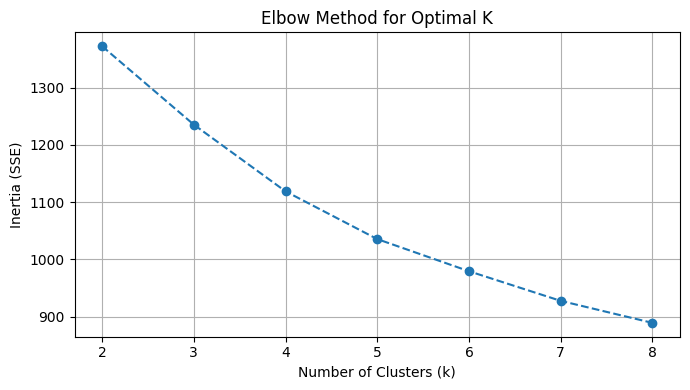

그래프 해석: 곡선이 꺾이는 지점(엘보우)을 확인하여 적절한 군집 개수를 결정합니다.


In [5]:
ks = range(2, 9)
inertias = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

# Elbow Method 시각화: 급격히 꺾이는 지점이 최적의 k입니다.
plt.figure(figsize=(7,4))
plt.plot(list(ks), inertias, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (SSE)')
plt.grid(True)
plt.tight_layout()
plt.show()

print('그래프 해석: 곡선이 꺾이는 지점(엘보우)을 확인하여 적절한 군집 개수를 결정합니다.')

## 5) KMeans 학습 및 군집 부여
- 여기서는 예시로 k=3을 사용합니다(원하면 바꿔보세요).


In [6]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df['cluster'] = clusters
df[['Date','Close','cluster']].head()


Price,Date,Close,cluster
Ticker,,TSLA,
0,2025-04-28,285.880005,2
1,2025-04-29,292.029999,2
2,2025-04-30,282.160004,2
3,2025-05-01,280.519989,2
4,2025-05-02,287.209991,2


## ✅ 마지막 시각화: PCA 2D 군집 시각화 + 종가 시계열에 군집 색칠
마지막에 반드시 ‘눈으로 보이는’ 결과가 나오도록 2개 그래프를 그립니다.


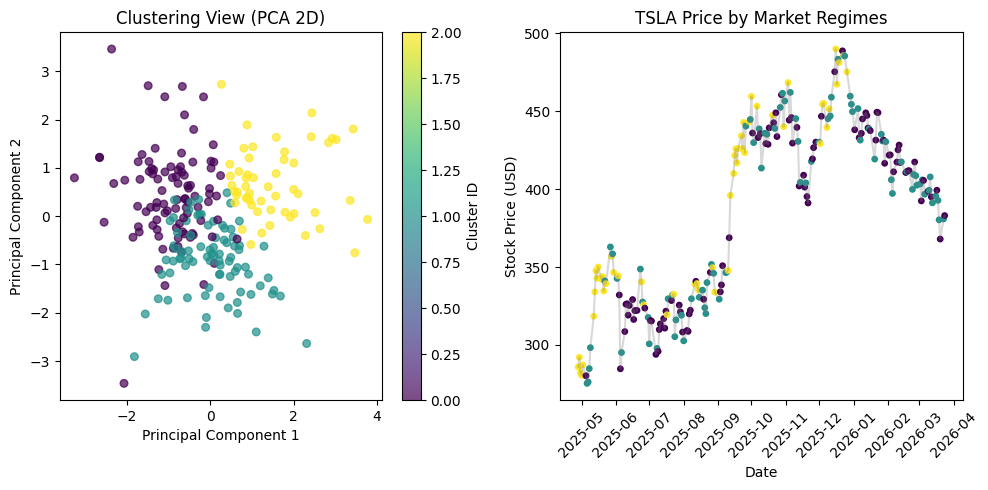

시각화 결과 해석:
1. 왼쪽 그래프: 각 점들은 하루를 의미하며, 색상이 같은 점들은 시장 성격이 비슷한 날들입니다.
2. 오른쪽 그래프: 주가 흐름 속에서 특정 군집이 언제 발생하는지 알 수 있습니다.
   예: 고변동성 하락장에서 특정 군집이 집중적으로 나타날 수 있습니다.


In [7]:
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

# 1. PCA를 이용한 2차원 공간에서의 군집 분포
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
scatter = plt.scatter(X_2d[:,0], X_2d[:,1], c=df['cluster'], cmap='viridis', s=30, alpha=0.7)
plt.title('Clustering View (PCA 2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, label='Cluster ID')

# 2. 실제 주가 차트에 군집 정보 투영
plt.subplot(1, 2, 2)
plt.plot(df['Date'], df['Close'], color='gray', alpha=0.3, label='Price Trend')
plt.scatter(df['Date'], df['Close'], c=df['cluster'], cmap='viridis', s=15)
plt.title('TSLA Price by Market Regimes')
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print('시각화 결과 해석:')
print('1. 왼쪽 그래프: 각 점들은 하루를 의미하며, 색상이 같은 점들은 시장 성격이 비슷한 날들입니다.')
print('2. 오른쪽 그래프: 주가 흐름 속에서 특정 군집이 언제 발생하는지 알 수 있습니다.')
print('   예: 고변동성 하락장에서 특정 군집이 집중적으로 나타날 수 있습니다.')

## ✅ 요약(3줄)
1) KMeans는 예측이 아니라 ‘비슷한 날들의 패턴’을 군집화해 레짐을 탐지합니다.
2) 군집은 상승/하락과 1:1로 대응하지 않을 수 있으며, 변동성/추세 상태를 나타낼 수 있습니다.
3) 군집 결과는 이후 ‘레짐별 예측 모델’을 따로 두는 방식으로 확장할 수 있습니다.
